In [1]:
import pandas as pd
import numpy as np

retail_df = pd.read_csv(
    "../../02_Cleaned_Data/online_retail_cleaned.csv"
)

retail_df.shape

(779425, 8)

In [2]:
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 47.6 MB


In [4]:
retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"])

retail_df["Customer ID"] = retail_df["Customer ID"].astype(int)

retail_df["Revenue"] = (
    retail_df["Quantity"] *
    retail_df["Price"]
)

retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  str           
 8   Revenue      779425 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(3)
memory usage: 53.5 MB


In [5]:
retail_df[
    ["Quantity","Price","Revenue"]
].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [6]:
customer_clv = retail_df.groupby("Customer ID").agg({
    "Revenue":"sum"
}).reset_index()

customer_clv.columns = [
    "Customer ID",
    "Total_Revenue"
]

customer_clv.head()

,Customer ID,Total_Revenue
0,12346,77556.46
1,12347,4921.53
2,12348,2019.40
3,12349,4428.69
4,12350,334.40


In [7]:
customer_clv.describe()

,Customer ID,Total_Revenue
count,5878.000000,5878.000000
mean,15315.313542,2955.904095
std,1715.572666,14440.852688
min,12346.000000,2.950000
25%,13833.250000,342.280000
50%,15314.500000,867.740000
75%,16797.750000,2248.305000
max,18287.000000,580987.040000


In [8]:
customer_frequency = retail_df.groupby("Customer ID").agg({
    "Invoice":"nunique"
}).reset_index()

customer_frequency.columns = [
    "Customer ID",
    "Purchase_Frequency"
]

customer_frequency.head()

,Customer ID,Purchase_Frequency
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1


In [9]:
customer_frequency.describe()

,Customer ID,Purchase_Frequency
count,5878.000000,5878.000000
mean,15315.313542,6.289384
std,1715.572666,13.009406
min,12346.000000,1.000000
25%,13833.250000,1.000000
50%,15314.500000,3.000000
75%,16797.750000,7.000000
max,18287.000000,398.000000


In [10]:
clv_df = customer_clv.merge(
    customer_frequency,
    on="Customer ID"
)

clv_df.head()

,Customer ID,Total_Revenue,Purchase_Frequency
0,12346,77556.46,12
1,12347,4921.53,8
2,12348,2019.40,5
3,12349,4428.69,4
4,12350,334.40,1


In [11]:
clv_df.shape

(5878, 3)

In [12]:
clv_df.describe()

,Customer ID,Total_Revenue,Purchase_Frequency
count,5878.000000,5878.000000,5878.000000
mean,15315.313542,2955.904095,6.289384
std,1715.572666,14440.852688,13.009406
min,12346.000000,2.950000,1.000000
25%,13833.250000,342.280000,1.000000
50%,15314.500000,867.740000,3.000000
75%,16797.750000,2248.305000,7.000000
max,18287.000000,580987.040000,398.000000


In [13]:
clv_df["CLV_Segment"] = "Low Value"

clv_df.loc[
    clv_df["Total_Revenue"] >= clv_df["Total_Revenue"].quantile(0.75),
    "CLV_Segment"
] = "Medium Value"

clv_df.loc[
    clv_df["Total_Revenue"] >= clv_df["Total_Revenue"].quantile(0.90),
    "CLV_Segment"
] = "High Value"

clv_df["CLV_Segment"].value_counts()

CLV_Segment
Low Value       4408
Medium Value     882
High Value       588
Name: count, dtype: int64

In [14]:
clv_df.groupby("CLV_Segment")["Total_Revenue"] \
      .agg(["count","sum","mean"]) \
      .round(2)

,count,sum,mean
CLV_Segment,,,
High Value,588,11107134.78,18889.68
Low Value,4408,3198031.51,725.51
Medium Value,882,3069637.99,3480.32


In [15]:
clv_df.sort_values(
    by="Total_Revenue",
    ascending=False
).head(10)

,Customer ID,Total_Revenue,Purchase_Frequency,CLV_Segment
5692,18102,580987.04,145,High Value
2277,14646,528602.52,151,High Value
1789,14156,313437.62,156,High Value
2538,14911,291420.81,398,High Value
5050,17450,244784.25,51,High Value
1331,13694,195640.69,143,High Value
5109,17511,172132.87,60,High Value
4061,16446,168472.50,2,High Value
4295,16684,147142.77,55,High Value
68,12415,144458.37,28,High Value


In [16]:
clv_df.to_csv(
    "../../02_Cleaned_Data/customer_clv.csv",
    index=False
)

In [17]:
clv_df.shape

(5878, 4)

In [18]:
import pandas as pd

clv_df = pd.read_csv(
    "../../02_Cleaned_Data/customer_clv.csv"
)

clv_df.head()

,Customer ID,Total_Revenue,Purchase_Frequency,CLV_Segment
0,12346,77556.46,12,High Value
1,12347,4921.53,8,Medium Value
2,12348,2019.40,5,Low Value
3,12349,4428.69,4,Medium Value
4,12350,334.40,1,Low Value


In [19]:
clv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         5878 non-null   int64  
 1   Total_Revenue       5878 non-null   float64
 2   Purchase_Frequency  5878 non-null   int64  
 3   CLV_Segment         5878 non-null   str    
dtypes: float64(1), int64(2), str(1)
memory usage: 183.8 KB


In [20]:
clv_df.describe()

,Customer ID,Total_Revenue,Purchase_Frequency
count,5878.000000,5878.000000,5878.000000
mean,15315.313542,2955.904095,6.289384
std,1715.572666,14440.852688,13.009406
min,12346.000000,2.950000,1.000000
25%,13833.250000,342.280000,1.000000
50%,15314.500000,867.740000,3.000000
75%,16797.750000,2248.305000,7.000000
max,18287.000000,580987.040000,398.000000


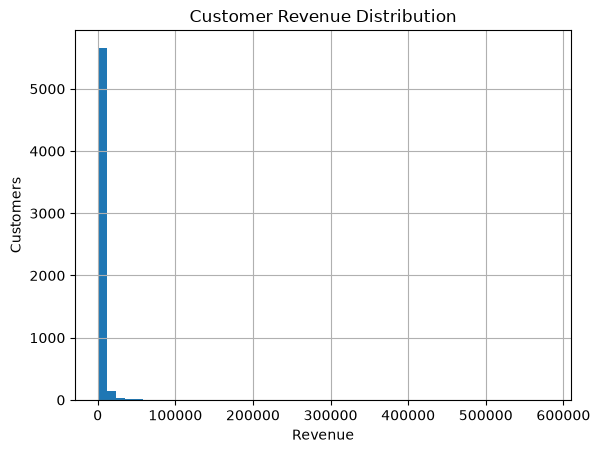

In [21]:
import matplotlib.pyplot as plt

clv_df["Total_Revenue"].hist(
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Customers")

plt.show()

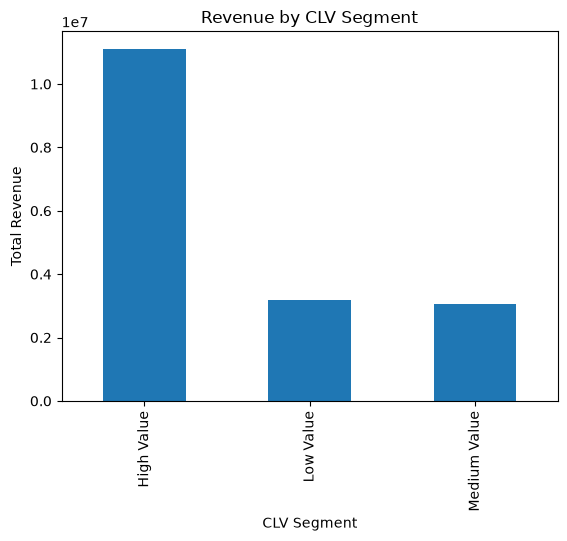

In [22]:
clv_df.groupby("CLV_Segment")["Total_Revenue"] \
      .sum() \
      .sort_values(ascending=False) \
      .plot(kind="bar")

plt.title("Revenue by CLV Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Total Revenue")

plt.show()

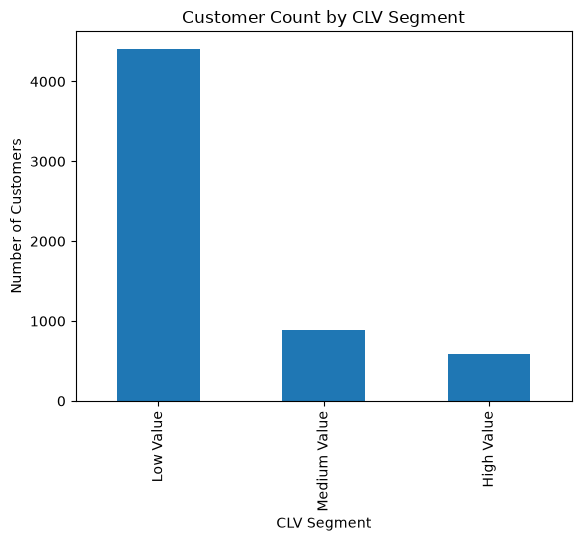

In [23]:
clv_df["CLV_Segment"] \
      .value_counts() \
      .plot(kind="bar")

plt.title("Customer Count by CLV Segment")
plt.xlabel("CLV Segment")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
clv_df.groupby("CLV_Segment").agg({
    "Customer ID":"count",
    "Total_Revenue":"sum",
    "Purchase_Frequency":"mean"
}).round(2)

,Customer ID,Total_Revenue,Purchase_Frequency
CLV_Segment,,,
High Value,588,11107134.78,27.03
Low Value,4408,3198031.51,2.86
Medium Value,882,3069637.99,9.61


# Customer Lifetime Value Analysis Summary

## Objective
Identify high-value customers and measure customer contribution.

## Key Findings
- High Value customers contribute the majority of total revenue.
- Most customers belong to the Low Value segment.
- Purchase frequency strongly influences customer value.
- Revenue distribution is highly concentrated among top customers.

## Recommendations
- Prioritize retention of High Value customers.
- Increase engagement of Medium Value customers.
- Develop loyalty programs for top spenders.
- Monitor CLV regularly for marketing optimization.

# Fixing Data Leakage

In [25]:
clv_df.columns

Index(['Customer ID', 'Total_Revenue', 'Purchase_Frequency', 'CLV_Segment'], dtype='str')

In [26]:
list(clv_df.columns)

['Customer ID', 'Total_Revenue', 'Purchase_Frequency', 'CLV_Segment']

In [27]:
clv_df= clv_df.drop(columns=["Customer ID"])
list(clv_df.columns)

['Total_Revenue', 'Purchase_Frequency', 'CLV_Segment']

In [28]:
clv_df.head()

,Total_Revenue,Purchase_Frequency,CLV_Segment
0,77556.46,12,High Value
1,4921.53,8,Medium Value
2,2019.40,5,Low Value
3,4428.69,4,Medium Value
4,334.40,1,Low Value


# CLV Model Rebuild (Leakage Free)

In [29]:
import pandas as pd
clv_df=pd.read_csv("../../02_cleaned_Data/customer_clv.csv")

clv_df.head()

,Customer ID,Total_Revenue,Purchase_Frequency,CLV_Segment
0,12346,77556.46,12,High Value
1,12347,4921.53,8,Medium Value
2,12348,2019.40,5,Low Value
3,12349,4428.69,4,Medium Value
4,12350,334.40,1,Low Value


In [30]:
clv_df= clv_df.drop(columns=["Total_Revenue", "Customer ID"])
clv_df.head()

,Purchase_Frequency,CLV_Segment
0,12,High Value
1,8,Medium Value
2,5,Low Value
3,4,Medium Value
4,1,Low Value


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

clv_df["CLV_Segment"]= le.fit_transform(clv_df["CLV_Segment"])
clv_df.head()

,Purchase_Frequency,CLV_Segment
0,12,0
1,8,2
2,5,1
3,4,2
4,1,1


In [32]:
from sklearn.model_selection import train_test_split
X= clv_df.drop("CLV_Segment", axis=1)
y= clv_df["CLV_Segment"]

X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)

X Train Shape: (4702, 1)
X Test Shape: (1176, 1)


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8656462585034014

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.66      0.73       112
           1       0.92      0.96      0.94       913
           2       0.51      0.48      0.49       151

    accuracy                           0.87      1176
   macro avg       0.75      0.70      0.72      1176
weighted avg       0.86      0.87      0.86      1176



In [34]:
X.columns

Index(['Purchase_Frequency'], dtype='str')

In [35]:
customer_clv.head()

,Customer ID,Total_Revenue
0,12346,77556.46
1,12347,4921.53
2,12348,2019.40
3,12349,4428.69
4,12350,334.40


In [36]:
customer_frequency.head()

,Customer ID,Purchase_Frequency
0,12346,12
1,12347,8
2,12348,5
3,12349,4
4,12350,1


In [37]:
clv_model_df= customer_clv.merge(
    customer_frequency,
    on= "Customer ID"
)
clv_model_df.head()

,Customer ID,Total_Revenue,Purchase_Frequency
0,12346,77556.46,12
1,12347,4921.53,8
2,12348,2019.40,5
3,12349,4428.69,4
4,12350,334.40,1


In [38]:
clv_model_df.shape

(5878, 3)

In [39]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'retail_df', '_1', '_i2', '_2', '_i3', '_i4', '_i5', '_5', '_i6', 'customer_clv', '_6', '_i7', '_7', '_i8', 'customer_frequency', '_8', '_i9', '_9', '_i10', 'clv_df', '_10', '_i11', '_11', '_i12', '_12', '_i13', '_13', '_i14', '_14', '_i15', '_15', '_i16', '_i17', '_17', '_i18', '_18', '_i19', '_i20', '_20', '_i21', 'plt', '_i22', '_i23', '_i24', '_24', '_i25', '_25', '_i26', '_26', '_i27', '_27', '_i28', '_28', '_i29', '_29', '_i30', '_30', '_i31', 'LabelEncoder', 'le', '_31', '_i32', 'train_test_split', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test', '_i33', 'RandomForestClassifier', 'accuracy_score', 'classification_report', 'rf_model', 'y_pred', '_i34', '_34', '_i35', '_35', '_i36', '_36', '_i37', 'clv_model_df', '_37', '_i

In [40]:
[name for name in globals().keys() if "rfm" in name.lower()]

[]

In [41]:
import pandas as pd 
segments_df= pd.read_csv("../../02_Cleaned_Data/customer_segments.csv")
segments_df.head()

,Customer ID,InvoiceDate,Recency,Purchase_Frequency,Monetary_Value,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,18-01-2011 10:01,326,12,77556.46,2,5,5,255,At Risk
1,12347,07-12-2011 15:52,2,8,4921.53,5,4,5,545,At Risk
2,12348,25-09-2011 13:13,75,5,2019.40,3,4,4,344,At Risk
3,12349,21-11-2011 09:51,19,4,4428.69,5,3,5,535,At Risk
4,12350,02-02-2011 16:01,310,1,334.40,2,1,2,212,Lost Customers


In [42]:
segments_df.shape

(5878, 10)

In [43]:
segments_df["Segment"].value_counts()

Segment
At Risk            3254
Lost Customers     1449
Others              978
Loyal Customers     137
Champions            60
Name: count, dtype: int64

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8656462585034014

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.66      0.73       112
           1       0.92      0.96      0.94       913
           2       0.51      0.48      0.49       151

    accuracy                           0.87      1176
   macro avg       0.75      0.70      0.72      1176
weighted avg       0.86      0.87      0.86      1176



In [45]:
segments_df.columns

Index(['Customer ID', 'InvoiceDate', 'Recency', 'Purchase_Frequency',
       'Monetary_Value', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
       'Segment'],
      dtype='str')

In [46]:
segments_df["CLV_Segment"] = "Low Value"

segments_df.loc[
    segments_df["Segment"] == "At Risk",
    "CLV_Segment"
] = "Medium Value"

segments_df.loc[
    segments_df["Segment"].isin(
        ["Champions", "Loyal Customers"]
    ),
    "CLV_Segment"
] = "High Value"

In [47]:
segments_df.columns

Index(['Customer ID', 'InvoiceDate', 'Recency', 'Purchase_Frequency',
       'Monetary_Value', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
       'Segment', 'CLV_Segment'],
      dtype='str')

In [48]:
segments_df[
    ["Segment","CLV_Segment"]
].sample(20)

,Segment,CLV_Segment
5384,Others,Low Value
3352,At Risk,Medium Value
4426,At Risk,Medium Value
5326,At Risk,Medium Value
3883,Lost Customers,Low Value
5085,Others,Low Value
5258,Others,Low Value
1067,At Risk,Medium Value
5699,At Risk,Medium Value
3740,At Risk,Medium Value


In [49]:
segments_df["CLV_Segment"].value_counts()

CLV_Segment
Medium Value    3254
Low Value       2427
High Value       197
Name: count, dtype: int64

In [50]:
features = [
    "Recency",
    "Purchase_Frequency",
    "Monetary_Value",
    "R_Score",
    "F_Score",
    "M_Score"
]

X = segments_df[features]
y = segments_df["CLV_Segment"]

print(X.shape)
print(y.shape)

(5878, 6)
(5878,)


In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['High Value' 'Low Value' 'Medium Value']


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(4702, 6)
(1176, 6)


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [54]:
y_pred = rf_model.predict(X_test)

In [55]:
list(X.columns)

['Recency',
 'Purchase_Frequency',
 'Monetary_Value',
 'R_Score',
 'F_Score',
 'M_Score']

In [56]:
X.columns

Index(['Recency', 'Purchase_Frequency', 'Monetary_Value', 'R_Score', 'F_Score',
       'M_Score'],
      dtype='str')

In [57]:
segments_df.head()

,Customer ID,InvoiceDate,Recency,Purchase_Frequency,Monetary_Value,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV_Segment
0,12346,18-01-2011 10:01,326,12,77556.46,2,5,5,255,At Risk,Medium Value
1,12347,07-12-2011 15:52,2,8,4921.53,5,4,5,545,At Risk,Medium Value
2,12348,25-09-2011 13:13,75,5,2019.40,3,4,4,344,At Risk,Medium Value
3,12349,21-11-2011 09:51,19,4,4428.69,5,3,5,535,At Risk,Medium Value
4,12350,02-02-2011 16:01,310,1,334.40,2,1,2,212,Lost Customers,Low Value


In [58]:
segments_df["Segment"].value_counts()

Segment
At Risk            3254
Lost Customers     1449
Others              978
Loyal Customers     137
Champions            60
Name: count, dtype: int64

In [59]:
segments_df["High_Value_Customer"] = (
    segments_df["Segment"]
    .isin(["Champions", "Loyal Customers"])
    .astype(int)
)

segments_df["High_Value_Customer"].value_counts()

High_Value_Customer
0    5681
1     197
Name: count, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split

X = segments_df[
    [
        "Recency",
        "Purchase_Frequency",
        "Monetary_Value",
        "R_Score",
        "F_Score",
        "M_Score"
    ]
]

y = segments_df["High_Value_Customer"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Distribution:")
print(y_train.value_counts())

print("\nTest Distribution:")
print(y_test.value_counts())

Train Distribution:
High_Value_Customer
0    4544
1     158
Name: count, dtype: int64

Test Distribution:
High_Value_Customer
0    1137
1      39
Name: count, dtype: int64


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

In [62]:
list(X.columns)

['Recency',
 'Purchase_Frequency',
 'Monetary_Value',
 'R_Score',
 'F_Score',
 'M_Score']

In [63]:
X = segments_df[
    [
        "Recency",
        "Purchase_Frequency",
        "Monetary_Value"
    ]
]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1137
           1       0.90      0.95      0.93        39

    accuracy                           0.99      1176
   macro avg       0.95      0.97      0.96      1176
weighted avg       1.00      0.99      0.99      1176



In [65]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Recency,0.675938
2,Monetary_Value,0.187773
1,Purchase_Frequency,0.136290


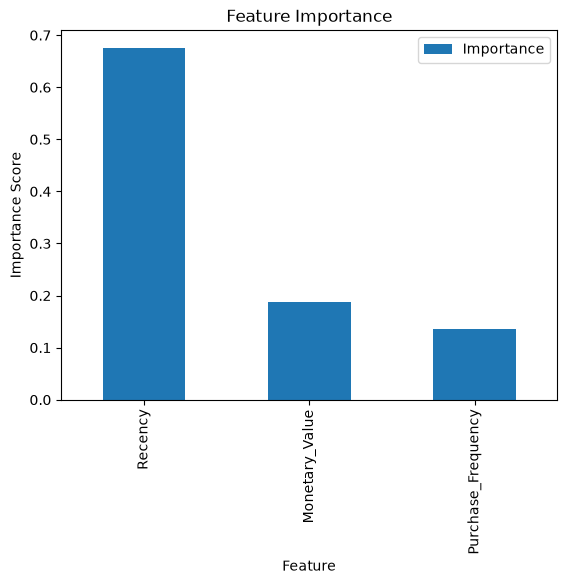

In [66]:
import matplotlib.pyplot as plt

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [67]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88      1137
           1       0.13      1.00      0.24        39

    accuracy                           0.79      1176
   macro avg       0.57      0.89      0.56      1176
weighted avg       0.97      0.79      0.85      1176



In [69]:
import pandas as pd

lr_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

lr_importance = lr_importance.sort_values(
    by="Coefficient",
    ascending=False
)

lr_importance

,Feature,Coefficient
1,Purchase_Frequency,0.062689
0,Recency,0.011794
2,Monetary_Value,-0.000021


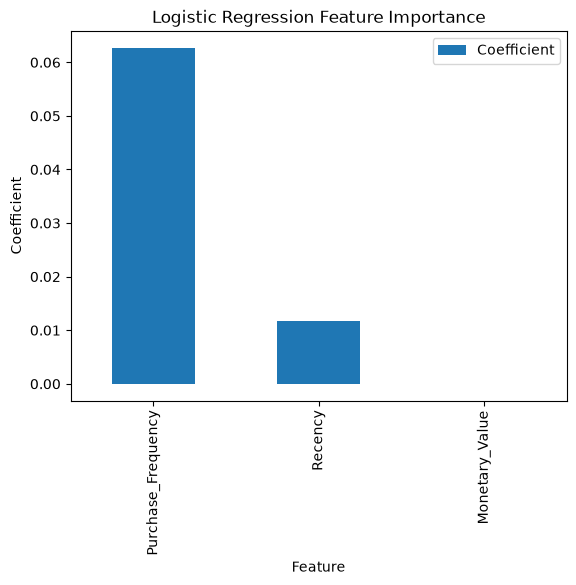

In [70]:
import matplotlib.pyplot as plt

lr_importance.plot(
    x="Feature",
    y="Coefficient",
    kind="bar"
)

plt.title("Logistic Regression Feature Importance")
plt.ylabel("Coefficient")
plt.show()

In [71]:
import xgboost
print (xgboost.__version__)

3.2.0


In [72]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1137
           1       1.00      0.95      0.97        39

    accuracy                           1.00      1176
   macro avg       1.00      0.97      0.99      1176
weighted avg       1.00      1.00      1.00      1176



In [74]:
import pandas as pd

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
1,Purchase_Frequency,0.406478
0,Recency,0.354147
2,Monetary_Value,0.239375


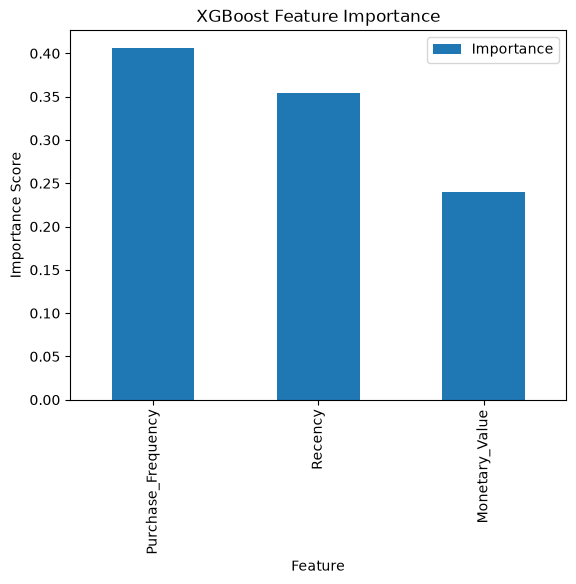

In [75]:
import matplotlib.pyplot as plt

xgb_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.show()

### XGBoost Feature Importance

Purchase Frequency emerged as the strongest predictor of High Value Customers, followed by Recency and Monetary Value. This indicates that customer buying behavior and engagement frequency play a significant role in determining long-term customer value.

In [80]:
ml_df = segments_df[
    [
        "Recency",
        "Purchase_Frequency",
        "Monetary_Value",
        "R_Score",
        "F_Score",
        "M_Score",
        "CLV_Segment"
    ]
]

ml_df.to_csv(
    "../../02_Cleaned_Data/customer_clv_ml.csv",
    index=False
)

print("customer_clv_ml.csv exported successfully")

customer_clv_ml.csv exported successfully
